In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [72]:
df = pd.read_json('../data/Prepared/car_data.json')

## Data contract (Data Dictionary + Validity Rules)

The dataset in `data/raw/car_data.json` and `data/Prepared/car_data.json` currently uses the same column schema. The table below documents the expected meaning, type, and validation rules for each field.

So this works as checklist when cleaning data.

| Column | Meaning | Type | Valid range/values | Units | Notes |
| --- | --- | --- | --- | --- | --- |
| `url` | listing URL | string | expected to be a valid OLX posting URL | - | should identify a posting, but duplicates are present in the current data |
| `posting_date` | date the listing was posted | date string | usually `DD.MM.YYYY`; some rows use relative text such as `Сегодня` | date | must be normalized before date parsing |
| `region` | seller region in Uzbekistan | category | 13 observed region values including `Tashkent`, `Samarkand`, `Bukhara`, `Karakalpakstan` | - | 1 missing value observed |
| `district` | district or city within a region | category | 230 observed values | - | spelling and naming normalization may be needed |
| `price` | listed sale price | numeric stored as string | positive values; observed range `10,000,000` to `2,008,972,671` | local currency | 5 missing values observed; outliers should be reviewed |
| `currency` | currency code for `price` | category | mostly `UZS` when present | ISO currency code | highly sparse in the current data; many rows are missing |
| `description` | free-text ad description | text | arbitrary seller-written text | - | noisy multilingual text; useful for NLP/features after cleaning |
| `image_url` | main image link for the ad | string | expected `http`/`https` image URL | - | optional; missing values are present |
| `seller_type` | seller classification | category | mostly `private` in observed data | - | many missing values; could later include dealer/business labels |
| `model` | vehicle model name | category/text | 720 observed values | - | may mix trims, generations, and inconsistent naming |
| `body_type` | vehicle body style | category | `Sedan`, `Hatchback`, `Station Wagon`, `SUV`, `Minivan`, `Pickup`, `Coupe`, `Convertible`, `Other` | - | appears complete in the current snapshot |
| `sale_type` | sale terms attached to the listing | multi-label text/category | values such as `Simple Sale`, `Credit`, `Installment`, `Exchange`, `Rent`, often comma-separated combinations | - | multilingual and highly inconsistent; many missing values |
| `year` | vehicle manufacture year | integer stored as string | observed range `1900` to `2025` | year | should be checked against realistic car production years |
| `mileage` | vehicle mileage | integer stored as string | observed range `0` to `10,000,000` | km | missing values and obvious outliers are possible |
| `transmission` | gearbox type | category | `Manual`, `Automatic`, `Other` | - | appears complete in the current snapshot |
| `color` | vehicle color | category | 23 observed color values such as `White`, `Black`, `Gray`, `Blue` | - | synonyms may need consolidation |
| `engine_volume` | engine size | numeric stored as string | observed range `1` to `10000` | unclear/mixed | scale is inconsistent across rows and likely needs normalization before analysis |
| `fuel_type` | fuel system | category | `Gasoline/Gas`, `Gasoline`, `Electric`, `Hybrid`, `Diesel`, `Other` | - | appears complete in the current snapshot |
| `condition` | vehicle condition | category | `Excellent`, `Good`, `Average`, `Needs Repair` | - | ordinal meaning should be preserved if encoded |
| `owners_count` | number of previous owners | ordinal category stored as string | `1`, `2`, `3`, `4+` | owners | missing values are present; `4+` is grouped rather than exact |
| `additional_options` | extra features/options listed in the ad | comma-separated text list | examples include `Customs Cleared`, `Electrical Window Lifters`, parking sensors, etc. | - | multi-valued field; multilingual, sparse, and suitable for splitting into tags |

## Data intake & first checks

### Basic intake checklist:

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 47156 entries, 0 to 47155
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   url                 47156 non-null  object 
 1   posting_date        47149 non-null  object 
 2   region              47148 non-null  object 
 3   district            47148 non-null  object 
 4   price               47144 non-null  object 
 5   currency            12614 non-null  object 
 6   description         47149 non-null  object 
 7   image_url           45520 non-null  object 
 8   seller_type         39798 non-null  object 
 9   model               47090 non-null  object 
 10  body_type           47149 non-null  object 
 11  sale_type           18749 non-null  object 
 12  year                47149 non-null  float64
 13  mileage             43852 non-null  float64
 14  transmission        47149 non-null  object 
 15  color               47149 non-null  object 
 16  engine_vo

### Uniqueness + duplicates

In [73]:
before = len(df)
print(f'Shape: {df.shape[0]}, {df.shape[1]}. Unique values: {df['url'].nunique()}')
df_clean = df.drop_duplicates(subset='url', keep='first').copy()
print(f'Removed elements: {before - len(df_clean)}')

Shape: 47307, 21. Unique values: 46307
Removed elements: 1000


### Target integrity check

The target variable (price) represents seller-listed prices, which may include noise due to negotiation strategies and inconsistent reporting.

##  Data quality audit (prove what’s wrong before fixing)

Data quality audit

|Column|% missing |Is missing acceptable?|Why might it be missing?|
|---|---|---|---|
|currency|73%|No|Scraper could not identify USD currency|
|sale_type|60%|Maybe|Sales type not included in description|
|model|1%|No|Model not included in description|
|mileage|7%|Yes(moderate, manageable)|Seller may be hide high usage, older listings may not include it|
|additional_options|34%|Yes|User forgot to include or none exist|

## Cleaning strategy (not just steps-decisions)

In [74]:
df_clean.tail(100)

,url,posting_date,region,district,price,currency,description,image_url,seller_type,model,...,sale_type,year,mileage,transmission,color,engine_volume,fuel_type,condition,owners_count,additional_options
47207,https://olx.uz/d/obyavlenie/matiz-best-srochna...,None,None,None,None,None,None,None,None,None,...,None,NaN,NaN,None,None,NaN,None,None,None,None
47208,https://olx.uz/d/obyavlenie/nexia-1-sotiladi-I...,Опубликовано28 апреля 2026,Tashkent,ТашкентАлмазарский район,1650..,USD,Описание 4 ta yangi balon qoyilgan mator ozim ...,None,None,Nexia,...,Simple Sale,1998.0,300000.0,Manual,White,1.0,Gasoline,Average,2,None
47209,https://olx.uz/d/obyavlenie/gaz-31-029-volga-I...,Опубликовано25 апреля 2026,Tashkent,ТашкентСергелийский район,1650..,USD,Описание Volga gaz 31 029 yuripturgan yaxshi m...,None,None,31,...,Simple Sale,1993.0,77777.0,Manual,White,2.0,Gasoline/Gas,Good,1,Security System
47210,https://olx.uz/d/obyavlenie/vaz-2110-lada2110-...,Опубликовано23 апреля 2026,Tashkent,Мирабад,1650..,USD,"Описание Lada 2110, 2008 год — на ходу, сел и ...",None,None,2110,...,Exchange,2008.0,278000.0,Manual,Silver,80.0,Gasoline/Gas,Average,3,Electrical Mirrors
47211,https://olx.uz/d/obyavlenie/matiz-1-650-yoki-a...,Опубликовано16 апреля 2026,Tashkent,ТашкентЧиланзарский район,1650..,USD,Описание Arenda matiz Telfon 94 639 24 47 90 9...,None,None,Matiz,...,None,2004.0,NaN,Manual,White,1.0,Gasoline,Average,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47302,https://olx.uz/d/obyavlenie/juguli-sotiladi-yi...,Опубликовано23 апреля 2026,Syrdarya,Баяут,20000000,UZS,Описание 1989-yil Kiraska radnoy Benzinda Tex ...,None,None,2106,...,Simple Sale,1989.0,62943.0,Manual,Green,50.0,Gasoline,Good,1,None
47303,https://olx.uz/d/obyavlenie/niva-sotiladi-hola...,Опубликовано23 апреля 2026,Karakalpakstan,Турткуль,20000000,UZS,Описание Нива сотилади. Холати яхши. Юриб тури...,None,None,Прочее,...,Simple Sale,1982.0,NaN,Manual,White,1580.0,Gasoline,Good,None,None
47304,https://olx.uz/d/obyavlenie/volga-24-holati-ya...,Опубликовано23 апреля 2026,Samarkand,Лаиш,20000000,UZS,Описание Volga 1992 yili propan gaz bor holati...,None,None,None,...,Simple Sale,1992.0,58252.0,Manual,Magnolia,24.0,Gasoline/Gas,Good,1,Electrical Mirrors
47305,https://olx.uz/d/obyavlenie/zhiguli-2102-god-h...,Опубликовано23 апреля 2026,Tashkent,ТашкентСергелийский район,20000000,UZS,Описание Жигули ваз2102 хорошем состояний пох...,None,None,2102,...,Simple Sale,1982.0,85000.0,Manual,Blue,1200.0,Gasoline,Excellent,1,None


### Standardization rules (categorical)

#### Starting off with `model` column

In [78]:
df_clean['district'].value_counts()

district
Samarkand                      2844
TashkentSergeliyskiy rayon     2440
TashkentYunusabadskiy rayon    2346
Buhara                         2274
TashkentChilanzarskiy rayon    1940
                               ... 
ТашкентЯккасарайский район        1
Джума                             1
Назарбек                          1
Гулистан                          1
Бандихон                          1
Name: count, Length: 318, dtype: int64

The original model column contained inconsistent representations, including numeric codes, partial names, and mixed-language values. A mapping dictionary was created to standardize these into unified car names and extract brand information, improving feature quality for modeling.

In [8]:
model_to_name = {

    # LADA (VAZ)
    "2101": "Lada 2101",
    "2102": "Lada 2102",
    "2103": "Lada 2103",
    "2104": "Lada 2104",
    "2105": "Lada 2105",
    "2106": "Lada 2106",
    "2107": "Lada 2107",
    "2108": "Lada Samara 2108",
    "2109": "Lada Samara 2109",
    "21099": "Lada Samara 21099",
    "21011": "Lada 21011",
    "21013": "Lada 21013",
    "21033": "Lada 21033",
    "21060": "Lada 21060",
    "21061": "Lada 21061",
    "21063": "Lada 21063",
    "21071": "Lada 21071",
    "21073": "Lada 21073",
    "21083": "Lada Samara 21083",
    "21093": "Lada Samara 21093",
    "21102": "Lada 21102",
    "21103": "Lada 21103",
    "21106": "Lada 21106",
    "21111": "Lada 21111",
    "21124": "Lada 21124",
    "2121 Нива": "Lada Niva",
    "21214 Niva": "Lada Niva 21214",
    "4x4": "Lada Niva 4x4",
    "Дана": "Lada Niva Dana",
    "Kalina": "Lada Kalina",
    "1117 Kalina универсал": "Lada Kalina Wagon",
    "1118 Kalina седан": "Lada Kalina Sedan",
    "1119 Kalina хэтчбэк": "Lada Kalina Hatchback",
    "2110": "Lada 2110",
    "2111": "Lada 2111",
    "2112": "Lada 2112",
    "2113": "Lada 2113",
    "2114": "Lada 2114",
    "2115": "Lada 2115",

    # GAZ — Volga
    "21": "GAZ 21 Volga",
    "21М": "GAZ 21 Volga",
    "21Р": "GAZ 21 Volga",
    "21УС": "GAZ 21 Volga",
    "22": "GAZ 22 Volga",
    "24": "GAZ 24 Volga",
    "2401": "GAZ 2401",
    "2402": "GAZ 2402",
    "2410": "GAZ 2410 Volga",
    "3102": "GAZ 3102 Volga",
    "3102i": "GAZ 3102i",
    "31013": "GAZ 31013",
    "31029": "GAZ 31029",
    "3110": "GAZ 3110",
    "3111": "GAZ 3111",

    # GAZ — Pobeda
    "M-20": "GAZ Pobeda M-20",
    "20": "GAZ Pobeda",
    "20М": "GAZ Pobeda",

    # GAZ — Chaika / ZIM / M1
    "13 Чайка": "GAZ 13 Chaika",
    "ЗИМ": "GAZ 12 ZIM",
    "12 ЗИМ": "GAZ 12 ZIM",
    "М1": "GAZ M1",

    # GAZ — off-road / trucks
    "69": "GAZ 69",
    "51": "GAZ 51",
    "66": "GAZ 66",
    "67": "GAZ 67",

    # MOSKVICH / IZH
    "400": "Moskvich 400",
    "401": "Moskvich 401",
    "407": "Moskvich 407",
    "410": "Moskvich 410",
    "412": "Moskvich 412",
    "412 Э": "Moskvich 412",
    "2125 Комби": "Moskvich 2125 Kombi",
    "2136 Kombi": "Moskvich 2136 Kombi",
    "2137 Kombi": "Moskvich 2137 Kombi",
    "ASLK 2137": "Moskvich 2137",
    "2140": "Moskvich 2140",
    "ASLK 2140": "Moskvich 2140",
    "2141": "Moskvich 2141",
    "21412": "Moskvich 21412",

    # UAZ
    "469": "UAZ 469",
    "469Б": "UAZ 469",
    "2206": "UAZ 2206",
    "2715": "UAZ 2715",
    "3151": "UAZ 3151",
    "3159": "UAZ 3159",
    "3303": "UAZ 3303",
    "31512-010": "UAZ 31512",
    "31514-012": "UAZ 31514",
    "31519-010": "UAZ 31519",
    "Hunter": "UAZ Hunter",

    # ZAZ
    "965": "ZAZ 965",
    "968": "ZAZ 968",
    "968M": "ZAZ 968M",
    "1102 Таврия": "ZAZ Tavria",
    "1102": "ZAZ Tavria",
    "1111 Ока": "ZAZ Oka",
    "Sens": "ZAZ Sens",

    # DAEWOO (very important in Uzbekistan)
    "Matiz": "Daewoo Matiz",
    "Nexia": "Daewoo Nexia",
    "Damas": "Daewoo Damas",
    "Tico": "Daewoo Tico",
    "Espero": "Daewoo Espero",

    # CHEVROLET (UzAuto)
    "Lacetti": "Chevrolet Lacetti",
    "Gentra": "Chevrolet Gentra",
    "Cobalt": "Chevrolet Cobalt",
    "Spark": "Chevrolet Spark",
    "Malibu": "Chevrolet Malibu",
    "Tracker": "Chevrolet Tracker",
    "Onix": "Chevrolet Onix",
    "Captiva": "Chevrolet Captiva",

    # HYUNDAI
    "Sonata": "Hyundai Sonata",
    "Accent": "Hyundai Accent",
    "Elantra": "Hyundai Elantra",

    # KIA
    "Rio": "Kia Rio",
    "Sportage": "Kia Sportage",

    # VOLKSWAGEN
    "Passat": "Volkswagen Passat",
    "Golf": "Volkswagen Golf",
    "Golf III": "Volkswagen Golf III",
    "Golf VI": "Volkswagen Golf VI",
    "Jetta": "Volkswagen Jetta",
    "Transporter": "Volkswagen Transporter",
    "Scirocco": "Volkswagen Scirocco",

    # NISSAN
    "Maxima": "Nissan Maxima",
    "Skyline GT-R": "Nissan Skyline GT-R",
    "Bluebird": "Nissan Bluebird",
    "R Nessa": "Nissan R'nessa",
    "Pathfinder": "Nissan Pathfinder",

    # TOYOTA
    "Corolla": "Toyota Corolla",
    "Camry": "Toyota Camry",
    "Hiace": "Toyota Hiace",
    "Lite Ace": "Toyota LiteAce",
    "Starlet": "Toyota Starlet",

    # FORD
    "Escort": "Ford Escort",
    "Fiesta": "Ford Fiesta",
    "Scorpio": "Ford Scorpio",
    "Granada": "Ford Granada",
    "Five Hundred": "Ford Five Hundred",

    # MERCEDES-BENZ
    "190": "Mercedes-Benz 190",
    "C 250": "Mercedes-Benz C250",
    "E 230": "Mercedes-Benz E230",
    "SL 320": "Mercedes-Benz SL320",
    "S 550": "Mercedes-Benz S550",

    # BMW
    "520": "BMW 520",

    # HONDA
    "Civic": "Honda Civic",

    # OPEL
    "Vectra": "Opel Vectra",
    "Omega": "Opel Omega",
    "Ascona": "Opel Ascona",
    "Rekord": "Opel Rekord",
    "Admiral": "Opel Admiral",
    "Vivaro": "Opel Vivaro",

    # FIAT
    "Uno": "Fiat Uno",
    "Croma": "Fiat Croma",

    # garbage / unknown
    "Прочее": None,
    "Другая": None,
    "Pickup": None,
    "eT7": None,
    "51": None,   # truck — exclude from car analysis
    "66": None,   # truck
    "67": None,   # military jeep
}

In [9]:
brand_map = {

    # Daewoo
    "Tico": "Daewoo",
    "Matiz": "Daewoo",
    "Nexia": "Daewoo",
    "Damas": "Daewoo",
    "Espero": "Daewoo",

    # Chevrolet (UzAuto)
    "Lacetti": "Chevrolet",
    "Spark": "Chevrolet",
    "Cobalt": "Chevrolet",
    "Malibu": "Chevrolet",
    "Tracker": "Chevrolet",
    "Onix": "Chevrolet",
    "Gentra": "Chevrolet",
    "Captiva": "Chevrolet",

    # Volkswagen
    "Passat": "Volkswagen",
    "Golf": "Volkswagen",
    "Golf III": "Volkswagen",
    "Golf VI": "Volkswagen",
    "Jetta": "Volkswagen",
    "Transporter": "Volkswagen",
    "Scirocco": "Volkswagen",

    # Nissan
    "Maxima": "Nissan",
    "Skyline GT-R": "Nissan",
    "Bluebird": "Nissan",
    "R Nessa": "Nissan",
    "Pathfinder": "Nissan",

    # Hyundai
    "Sonata": "Hyundai",
    "Accent": "Hyundai",
    "Elantra": "Hyundai",

    # Kia
    "Rio": "Kia",
    "Sportage": "Kia",

    # Toyota
    "Corolla": "Toyota",
    "Camry": "Toyota",
    "Hiace": "Toyota",
    "Lite Ace": "Toyota",

    # Ford
    "Escort": "Ford",
    "Fiesta": "Ford",
    "Scorpio": "Ford",

    # Mercedes-Benz
    "190": "Mercedes-Benz",
    "C 250": "Mercedes-Benz",
    "SL 320": "Mercedes-Benz",

    # BMW
    "520": "BMW",

    # Opel
    "Vectra": "Opel",
    "Omega": "Opel",
    "Ascona": "Opel",
    "Rekord": "Opel",

    # Fiat
    "Uno": "Fiat",
    "Croma": "Fiat",

    # UAZ
    "469": "UAZ",
    "469Б": "UAZ",
    "3151": "UAZ",
    "3159": "UAZ",
    "3303": "UAZ",
    "2206": "UAZ",

    # ZAZ
    "968": "ZAZ",
    "968M": "ZAZ",
    "1102 Таврия": "ZAZ",
    "1102": "ZAZ",
    "1111 Ока": "ZAZ",

    # Moskvich / IZH
    "412": "Moskvich",
    "412 Э": "Moskvich",
    "2140": "Moskvich",
    "2141": "Moskvich",
    "21412": "Moskvich",
    "ASLK 2140": "Moskvich",
    "ASLK 2137": "Moskvich",
    "2137 Kombi": "Moskvich",
    "2136 Kombi": "Moskvich",

    # GAZ
    "24": "GAZ",
    "2410": "GAZ",
    "2401": "GAZ",
    "2402": "GAZ",
    "3102": "GAZ",
    "31029": "GAZ",
    "3110": "GAZ",
    "3102i": "GAZ",

    # Lada (VAZ)
    "2101": "Lada",
    "2102": "Lada",
    "2103": "Lada",
    "2104": "Lada",
    "2105": "Lada",
    "2106": "Lada",
    "2107": "Lada",
    "2108": "Lada",
    "2109": "Lada",
    "21011": "Lada",
    "21013": "Lada",
    "21051": "Lada",
    "21061": "Lada",
    "21071": "Lada",
    "21073": "Lada",
    "21083": "Lada",
    "21093": "Lada",
    "21099": "Lada",

    "2110": "Lada",
    "2111": "Lada",
    "2113": "Lada",
    "21106": "Lada",
    "21124": "Lada",

    "2121 Нива": "Lada",
    "21214 Niva": "Lada",
    "4x4": "Lada",

    "1117 Kalina универсал": "Lada",
    "1118 Kalina седан": "Lada",
    "1119 Kalina хэтчбэк": "Lada",

    # fallback garbage
    "Прочее": None,
    "Другая": None,
}

In [10]:
df_clean['model_clean'] = df_clean['model'].str.replace(":","", regex=False).str.strip()
print('Removed ":"')
df_clean['car_name'] = df_clean['model_clean'].map(model_to_name)


Removed ":"


In [11]:
def assign_brand(model):
    if model.isdigit():
        num = int(model)

        if 2100 <= num <= 2199:
            return 'Lada'
        
        elif num in [24, 31, 3102, 31029, 3110]:
            return 'GAZ'
        
        elif num in [80, 100, 200, 50]:
            return 'Audi'
        
        elif num in [2140, 2141, 412]:
            return 'Moskvich'
    return None
def get_brand(model):
    model = str(model)

    brand = assign_brand(model)
    if brand:
        return brand
    
    for key in brand_map:
        if key.lower()in model.lower():
            return brand_map[key]
    return "Other"

In [12]:
df_clean["brand"] = df_clean["model_clean"].apply(get_brand)
df_clean["car_name"] = df_clean["car_name"].fillna(df_clean["model_clean"])

- `groupby()` is used to find model names to find common brands based on model names
- Not all data points are equally important — high-frequency categories contribute most to model performance.

In [13]:
df_clean.groupby('model_clean')['model_clean'].count().sort_values(ascending=False)

model_clean
Nexia        6455
Lacetti      4982
Matiz        4295
Damas        3882
Cobalt       3551
             ... 
El Camino       1
21102           1
Regata          1
Econoline       1
E 420           1
Name: model_clean, Length: 720, dtype: int64

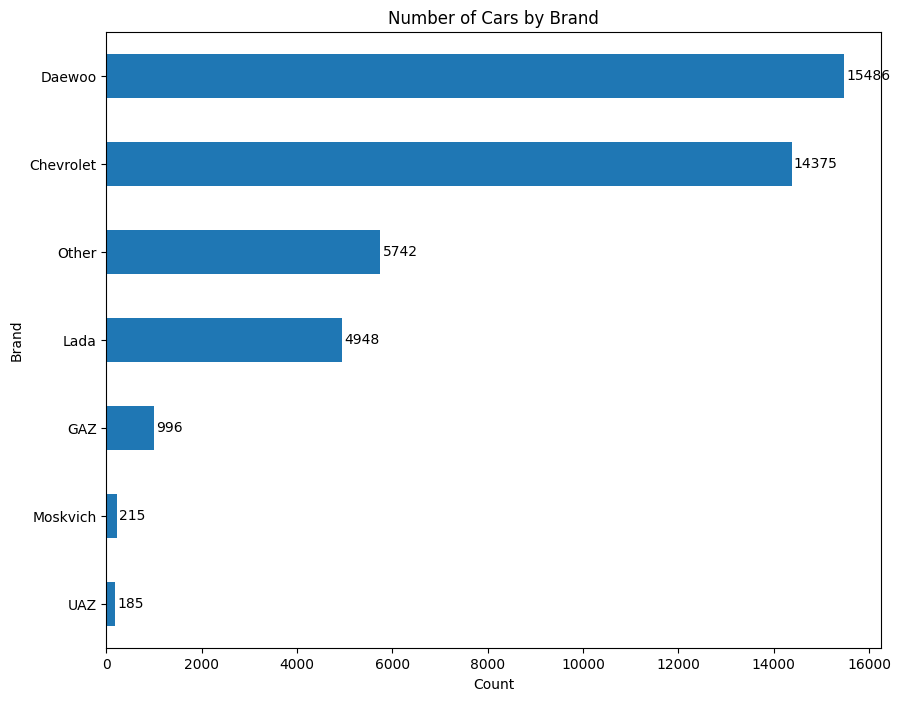

In [14]:
counts = df_clean.groupby('brand')['brand'].count().sort_values().tail(7)

ax = counts.plot(kind='barh', figsize=(10, 8))

for i, v in enumerate(counts):
    ax.text(v + 50, i, str(v), va='center')

plt.title("Number of Cars by Brand")
plt.xlabel("Count")
plt.ylabel("Brand")
plt.show()


- **What you see (facts):**  
  `Daewoo` and `Chevrolet` brands have the highest sales volume.

- **What it might mean (interpretation):**  
  These vehicles are widely available and popular in the market.  
  They can be considered **`best sellers`**, meaning they sell quickly and do not remain listed for long.

- **What you would do next (action/decision):**  
  Proceed to the next data cleaning stage.  
  Expanding brand mapping further is unlikely to significantly improve the analysis.

In [15]:
df_clean['brand'] = df_clean['brand'].fillna('Other')

In [16]:
df_clean.head()

,url,posting_date,region,district,price,currency,description,image_url,seller_type,model,...,transmission,color,engine_volume,fuel_type,condition,owners_count,additional_options,model_clean,car_name,brand
0,https://olx.uz/d/obyavlenie/vaz-2103-gazda-yur...,26.04.2025,Jizzakh,Gallaaral,15000000,UZS,Mator karobka zadnimos qilingan yili 1979,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 2103,...,Manual,Red,12,Gasoline/Gas,Good,2,None,2103,Lada 2103,Lada
1,https://olx.uz/d/obyavlenie/vaz2105zhuguli-god...,26.04.2025,Namangan,Namangan,15000000,UZS,Торг строга укапота машина на ходу полный раб...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 2105,...,Manual,Green,1,Gasoline/Gas,Average,1,None,2105,Lada 2105,Lada
2,https://olx.uz/d/obyavlenie/juguli-21011-sotil...,26.04.2025,Khorezm,Karaul,15000000,UZS,Mashin toxlangan metan 100 lik bo 14 diska b...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,None,: 2101,...,Manual,White,2103,Gasoline/Gas,Good,4+,None,2101,Lada 2101,Lada
3,https://olx.uz/d/obyavlenie/waxzod-kafolati-bi...,26.04.2025,Jizzakh,Mardzhanbulak,15000000,UZS,31029 96yil matori zor karopka zor magnitafon ...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 31029,...,Manual,White,105,Gasoline/Gas,Good,2,None,31029,GAZ 31029,GAZ
4,https://olx.uz/d/obyavlenie/mazda-626-starushk...,26.04.2025,Karakalpakstan,Kungrad,15000000,UZS,Прадаётсья на запчасти Мазда 626 старушка 1.6 ...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 626,...,Manual,White,16,Gasoline/Gas,Needs Repair,None,"Customs Cleared, Electrical Window Lifters, Па...",626,626,Other


In [17]:
df_clean = df_clean.rename(columns={"model":"model_raw"})

In [18]:
df_clean.head()

,url,posting_date,region,district,price,currency,description,image_url,seller_type,model_raw,...,transmission,color,engine_volume,fuel_type,condition,owners_count,additional_options,model_clean,car_name,brand
0,https://olx.uz/d/obyavlenie/vaz-2103-gazda-yur...,26.04.2025,Jizzakh,Gallaaral,15000000,UZS,Mator karobka zadnimos qilingan yili 1979,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 2103,...,Manual,Red,12,Gasoline/Gas,Good,2,None,2103,Lada 2103,Lada
1,https://olx.uz/d/obyavlenie/vaz2105zhuguli-god...,26.04.2025,Namangan,Namangan,15000000,UZS,Торг строга укапота машина на ходу полный раб...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 2105,...,Manual,Green,1,Gasoline/Gas,Average,1,None,2105,Lada 2105,Lada
2,https://olx.uz/d/obyavlenie/juguli-21011-sotil...,26.04.2025,Khorezm,Karaul,15000000,UZS,Mashin toxlangan metan 100 lik bo 14 diska b...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,None,: 2101,...,Manual,White,2103,Gasoline/Gas,Good,4+,None,2101,Lada 2101,Lada
3,https://olx.uz/d/obyavlenie/waxzod-kafolati-bi...,26.04.2025,Jizzakh,Mardzhanbulak,15000000,UZS,31029 96yil matori zor karopka zor magnitafon ...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 31029,...,Manual,White,105,Gasoline/Gas,Good,2,None,31029,GAZ 31029,GAZ
4,https://olx.uz/d/obyavlenie/mazda-626-starushk...,26.04.2025,Karakalpakstan,Kungrad,15000000,UZS,Прадаётсья на запчасти Мазда 626 старушка 1.6 ...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 626,...,Manual,White,16,Gasoline/Gas,Needs Repair,None,"Customs Cleared, Electrical Window Lifters, Па...",626,626,Other


In [19]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 46106 entries, 0 to 47105
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   url                 46106 non-null  object 
 1   posting_date        46106 non-null  object 
 2   region              46105 non-null  object 
 3   district            46105 non-null  object 
 4   price               46101 non-null  object 
 5   currency            12262 non-null  object 
 6   description         46106 non-null  object 
 7   image_url           44547 non-null  object 
 8   seller_type         39027 non-null  object 
 9   model_raw           46047 non-null  object 
 10  body_type           46106 non-null  object 
 11  sale_type           18321 non-null  object 
 12  year                46106 non-null  int64  
 13  mileage             42857 non-null  float64
 14  transmission        46106 non-null  object 
 15  color               46106 non-null  object 
 16  engine_vo

---

#### Price & currency
- OLX uses USD currency as a default. In out data, UZS only precent but USD is missing.
- UZS will be swapped to USD to maintain consistency.

In [20]:
df_clean.groupby('currency')['currency'].count()

currency
UZS    12262
Name: currency, dtype: int64

In [21]:
df_clean['currency'] = df_clean['currency'].fillna('USD')

In [22]:
df_clean.sample(5)

,url,posting_date,region,district,price,currency,description,image_url,seller_type,model_raw,...,transmission,color,engine_volume,fuel_type,condition,owners_count,additional_options,model_clean,car_name,brand
19732,https://olx.uz/d/obyavlenie/chevrolet-damas-ID...,05.05.2025,Samarkand,Samarkand,8200..,USD,Damas 2023 yurmagan narhini\n kelishamiz 8200$...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: Damas,...,Manual,White,38,Gasoline,Excellent,1,None,Damas,Daewoo Damas,Daewoo
44135,https://olx.uz/d/obyavlenie/tracer-2-ltz-turbo...,04.05.2025,Tashkent,Yangiyul,18000..,USD,Moshina holati zõr rangi qora toza moshina +99...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: Tracker,...,Automatic,Black,1,Gasoline/Gas,Excellent,1,None,Tracker,Chevrolet Tracker,Chevrolet
38079,https://olx.uz/d/obyavlenie/jentra-2021-avtoma...,09.05.2025,Tashkent,TashkentShayhantahurskiy rayon,13500..,USD,Jentra 2021\nHolati alo\nAutomatic karopka,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: Lacetti,...,Automatic,White,15,Gasoline,Good,1,"Air Conditioner, Electrical Mirrors, Парктрони...",Lacetti,Chevrolet Lacetti,Chevrolet
40722,https://olx.uz/d/obyavlenie/gentra-2021-ideal-...,03.05.2025,Jizzakh,Pahtakor,15000..,USD,Gentra 2021 ideal \nProbeg 65 ming halol \nKra...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: Lacetti,...,Manual,White,1,Gasoline/Gas,Excellent,1,"Air Conditioner, Electrical Mirrors, Electrica...",Lacetti,Chevrolet Lacetti,Chevrolet
20623,https://olx.uz/d/obyavlenie/mersedes-vito-2004...,21.04.2025,Surkhandarya,Baysun,8300..,USD,Mers vito holati a'lo mator yangi qilingan 646...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: Vito,...,Manual,White,24,Other,Good,1,"Security System, Electrical Mirrors, Electrica...",Vito,Vito,Other


In [23]:
exchange_rate = 12000

df_clean['price'] = pd.to_numeric(df_clean['price'].astype(str).str.replace(r'[^\d]', '', regex=True),
    errors='coerce'
)

df_clean['price_usd'] = df_clean['price']
df_clean.loc[df_clean['currency'] == 'UZS', 'price_usd'] = (
    df_clean.loc[df_clean['currency'] == 'UZS', 'price_usd'] / exchange_rate
).round(1)

`Currency` is now correctly formatted. Its ready for ml.

In [24]:
df_clean = df_clean.rename(columns={"price":"price_raw"})

In [25]:
df_clean.head()

,url,posting_date,region,district,price_raw,currency,description,image_url,seller_type,model_raw,...,color,engine_volume,fuel_type,condition,owners_count,additional_options,model_clean,car_name,brand,price_usd
0,https://olx.uz/d/obyavlenie/vaz-2103-gazda-yur...,26.04.2025,Jizzakh,Gallaaral,15000000.0,UZS,Mator karobka zadnimos qilingan yili 1979,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 2103,...,Red,12,Gasoline/Gas,Good,2,None,2103,Lada 2103,Lada,1250.0
1,https://olx.uz/d/obyavlenie/vaz2105zhuguli-god...,26.04.2025,Namangan,Namangan,15000000.0,UZS,Торг строга укапота машина на ходу полный раб...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 2105,...,Green,1,Gasoline/Gas,Average,1,None,2105,Lada 2105,Lada,1250.0
2,https://olx.uz/d/obyavlenie/juguli-21011-sotil...,26.04.2025,Khorezm,Karaul,15000000.0,UZS,Mashin toxlangan metan 100 lik bo 14 diska b...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,None,: 2101,...,White,2103,Gasoline/Gas,Good,4+,None,2101,Lada 2101,Lada,1250.0
3,https://olx.uz/d/obyavlenie/waxzod-kafolati-bi...,26.04.2025,Jizzakh,Mardzhanbulak,15000000.0,UZS,31029 96yil matori zor karopka zor magnitafon ...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 31029,...,White,105,Gasoline/Gas,Good,2,None,31029,GAZ 31029,GAZ,1250.0
4,https://olx.uz/d/obyavlenie/mazda-626-starushk...,26.04.2025,Karakalpakstan,Kungrad,15000000.0,UZS,Прадаётсья на запчасти Мазда 626 старушка 1.6 ...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 626,...,White,16,Gasoline/Gas,Needs Repair,None,"Customs Cleared, Electrical Window Lifters, Па...",626,626,Other,1250.0


---
#### mileage 


In [26]:
df['mileage'].describe()

count    4.381800e+04
mean     1.936853e+05
std      6.834135e+05
min      0.000000e+00
25%      3.500000e+02
50%      7.100000e+04
75%      2.030000e+05
max      1.000000e+07
Name: mileage, dtype: float64

In [27]:
df_clean["mileage"].sort_values(ascending=False)


7981     10000000.0
2254     10000000.0
2420     10000000.0
25087    10000000.0
24073    10000000.0
            ...    
47086           NaN
47087           NaN
47088           NaN
47091           NaN
47092           NaN
Name: mileage, Length: 46106, dtype: float64

That was the wildest part of the cleaning. `mileage` column has serius outliers / dirty values.

In [28]:
df_clean['mileage_raw'] = df_clean['mileage']
df_clean.loc[df_clean['mileage'] > 500000, 'mileage'] = np.nan

In [29]:
df_clean.sample(6)

,url,posting_date,region,district,price_raw,currency,description,image_url,seller_type,model_raw,...,engine_volume,fuel_type,condition,owners_count,additional_options,model_clean,car_name,brand,price_usd,mileage_raw
6077,https://olx.uz/d/obyavlenie/volga-2401-sotilad...,14.04.2025,Tashkent,TashkentUchtepinskiy rayon,2500.0,USD,Volga bor sotiladi qizqanla tel qsn 100 talik ...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 3111,...,24,Gasoline/Gas,Good,3,None,3111,GAZ 3111,Other,2500.0,NaN
40568,https://olx.uz/d/obyavlenie/hoji-2025-nasiya-v...,14.04.2025,Kashkadarya,Karshi,15000.0,USD,Hongqie E-qm5 \nYili 2025\n450km 15000$\n500...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,None,: Прочее,...,1500,Electric,Excellent,1,Customs Cleared,Прочее,Прочее,Other,15000.0,0.0
44626,https://olx.uz/d/obyavlenie/chevrolet-monza-1-...,25.04.2025,Tashkent,Angren,240500000.0,UZS,Chevrolet Monza 1.3 turbina mator\nyili 2025\n...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,None,: Monza,...,1500,Gasoline,Excellent,1,"Customs Cleared, Electrical Mirrors, Electrica...",Monza,Monza,Other,20041.7,0.0
11252,https://olx.uz/d/obyavlenie/srochno-prodaetsya...,28.04.2025,Tashkent,Zangiata,5800.0,USD,Срочно продается Daewoo Nexia 2 DONS 1.6. В от...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: Nexia,...,1,Gasoline/Gas,Excellent,None,None,Nexia,Daewoo Nexia,Daewoo,5800.0,335000.0
17446,https://olx.uz/d/obyavlenie/epika-sotiladi-200...,23.04.2025,Fergana,Fergana,7500.0,USD,Мошина сотилади моторни стволи янги куйилган у...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: Epica,...,2,Gasoline/Gas,Excellent,None,None,Epica,Epica,Other,7500.0,387000.0
26649,https://olx.uz/d/obyavlenie/neksiya-2-sotiladi...,06.04.2025,Fergana,Fergana,4500.0,USD,Нексия 2. 2010 йил. Пробег 400минг. Краска кап...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: Nexia,...,1500,Gasoline/Gas,Excellent,2,"Security System, Customs Cleared, Electrical W...",Nexia,Daewoo Nexia,Daewoo,4500.0,400000.0


In [30]:
df_clean['mileage'].isna().sum()

5108

In [31]:
df_clean.loc[
    df_clean["mileage"] == 0,
    ["car_name", "year", "mileage", "price_raw", "description"]
]


,car_name,year,mileage,price_raw,description
2,Lada 2101,1979,0.0,15000000.0,Mashin toxlangan metan 100 lik bo 14 diska b...
18,GAZ 2401,1983,0.0,15000000.0,Волга газ 2401 сотилади матор килинди \nапкатк...
32,GAZ 69,1982,0.0,15000000.0,Мошина ранги яашил матор килинса болди йуради ...
40,Lada 2106,1988,0.0,15000000.0,Prapanda moshina elektirkka kursatish kerak k...
65,Lada 2105,1983,0.0,15000000.0,Moshinani xarajati yoq mayda chuyda ozmoz ishi...
...,...,...,...,...,...
47089,Chazor,2024,0.0,302300000.0,Предлагаем вашему вниманию от BYD AUTOZONE (Лу...
47090,Chazor,2024,0.0,302300000.0,BYD Chazor dm-i гибрид 3 -4 позициялари бо...
47093,C11 EV,2025,0.0,301600000.0,Год выпуска - 2025 г.в.\nЗапас хода - NEDC - 4...
47096,Chevrolet Tracker,2023,0.0,23200.0,"Tracker 2, 2-pozitsiya avtomat, bez probeg so..."


- By looking at the results, a few insights were obtained:
    - Almost all old cars have mileage equal to 0, meaning the owners do not know the mileage count so they didn't specify it.
    - Maybe we will decide the mileage based on price and year.


In [32]:
df_clean.loc[(df_clean['mileage'] < 5000) & (df_clean['price_usd'] < 10000) & (df_clean['year'] < 2023), 'mileage'] = np.nan

This code is based on pure logic. If a car is old and mileage is too low than its not real. If a price also low that it indicates the car is used so those will be marked as missing.

In [33]:
df_clean.loc[(df_clean['mileage'] == 0) &
    (df_clean['year'] < 2024),
    'mileage'
] = np.nan

In [34]:
df_clean['mileage_log'] = np.log1p(df_clean['mileage'])


In [35]:
df_clean['mileage_group'] = pd.cut(
    df_clean['mileage'],
    bins=[-1, 15000, 50000, 100000, 200000, 500000],
    labels=['new_or_very_low', 'low', 'medium', 'high', 'very_high']
)


SO We know 

In [36]:
df_clean['mileage'].describe()

count     35346.000000
mean     126926.272591
std      125928.582811
min           0.000000
25%       11111.000000
50%       93000.000000
75%      206000.000000
max      500000.000000
Name: mileage, dtype: float64

#### engine_volume

In [37]:
df_clean['engine_volume'].value_counts()

engine_volume
1       10978
1500     4703
15       4666
16       2405
2        2089
        ...  
234         1
752         1
1895        1
628         1
1479        1
Name: count, Length: 779, dtype: int64

In [38]:
df_clean.loc[df_clean['engine_volume'] == 8, ['model_raw', 'year', 'engine_volume']]


,model_raw,year,engine_volume
116,: Tico,1999,8
197,: 2125 Комби,1988,8
314,: Tico,1996,8
552,: Tico,1997,8
565,: Tico,1998,8
...,...,...,...
44254,: Yuan Up,2025,8
44680,: Tracker,2023,8
44801,: Tracker,2023,8
46852,: Прочее,2022,8


Results suggest values in engine_volume mostly are incorrect. The data still contains noise. Some sellers put model id in engine_volume.


In [39]:
df_clean.loc[df_clean['engine_volume'] == 125]

,url,posting_date,region,district,price_raw,currency,description,image_url,seller_type,model_raw,...,condition,owners_count,additional_options,model_clean,car_name,brand,price_usd,mileage_raw,mileage_log,mileage_group
1245,https://olx.uz/d/obyavlenie/moskvich-21-41-mos...,06.04.2025,Tashkent,Chirchik,1500.0,USD,Москвич 2141 \n1990 г\nКелишамиз. Краска килин...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 2141,...,Average,1,Парктроник,2141,Moskvich 2141,Lada,1500.0,1000.0,NaN,NaN
1802,https://olx.uz/d/obyavlenie/06-jguli-sotiladi-...,21.04.2025,Navoi,Navoi,18000000.0,UZS,Metan o‘rnatilgan \nXarajati yo‘q\nHolati yaxshi,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 2106,...,Good,1,None,2106,Lada 2106,Lada,1500.0,333333.0,12.716900,very_high
1891,https://olx.uz/d/obyavlenie/zur-xolat-ala-ID3A...,25.04.2025,Samarkand,Dzhuma,21000000.0,UZS,Xolat. Yaxshi. Rurshi. Idal motor. Moy. Yemad...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,None,: 2106,...,Good,1,None,2106,Lada 2106,Lada,1750.0,NaN,NaN,NaN
2176,https://olx.uz/d/obyavlenie/gaz-3110-soltiladi...,08.04.2025,Bukhara,Buhara,20000000.0,UZS,Metan gaz bor 3 pakaleni. Kuzuvida ishlari bor...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 3110,...,Average,2,"Electrical Mirrors, Electrical Window Lifters,...",3110,GAZ 3110,GAZ,1666.7,300000.0,12.611541,very_high
3486,https://olx.uz/d/obyavlenie/moskvich-407-otlic...,28.04.2025,Bukhara,Buhara,25000000.0,UZS,Москвич 407 идеальный состояние 90 413 92 00,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 407,...,Excellent,1,Customs Cleared,407,Moskvich 407,Other,2083.3,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44014,https://olx.uz/d/obyavlenie/trecker-2-premier-...,06.05.2025,Khorezm,Pitnak,234000000.0,UZS,Xolati a'lo 2021 yil kareyski variant barcha m...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,None,: Tracker,...,Excellent,2,"Парктроник, Electrical Mirrors, Customs Cleare...",Tracker,Chevrolet Tracker,Chevrolet,19500.0,76000.0,11.238502,medium
44389,https://olx.uz/d/obyavlenie/tracker-2-primier-...,02.05.2025,Tashkent,TashkentUchtepinskiy rayon,19000.0,USD,Tracker 2 primier мошина топ тоза . Битта ко...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: Tracker,...,Excellent,1,"Air Conditioner, Customs Cleared, Electrical M...",Tracker,Chevrolet Tracker,Chevrolet,19000.0,17000.0,9.741027,low
45220,https://olx.uz/d/obyavlenie/1-yil-kafolat-bera...,09.05.2025,Bukhara,Galaasiya,250000000.0,UZS,Автомашина 2021 йилда ишлаб чикарилган 57 минг...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: Caddy,...,Excellent,1,None,Caddy,Caddy,Other,20833.3,57000.0,10.950824,medium
45659,https://olx.uz/d/obyavlenie/tracker-2-ltz-sht-...,02.05.2025,Khorezm,Urgench,263000000.0,UZS,Tracker 2 LTZ shòt 2023 yil nomer olinmagan òz...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: Tracker,...,Excellent,1,"Парктроник, Electrical Mirrors, Customs Cleare...",Tracker,Chevrolet Tracker,Chevrolet,21916.7,0.0,NaN,NaN


In [40]:

df_clean['engine_volume_raw'] = df_clean['engine_volume']

def format_engine_value(x):
    if pd.isna(x):
        return np.nan
    if x >= 1000:
        return x / 1000
    if 100 <= x < 1000:
        return x / 100
    if 10 <= x < 100:
        return x / 10
    if 0 < x < 10:
        return x
    return np.nan
df_clean['engine_volume_l'] = df_clean['engine_volume_raw'].apply(format_engine_value)


In [41]:
df_clean["engine_volume_l"].value_counts().sort_index()


engine_volume_l
1.000     11651
1.004         1
1.005         1
1.008         1
1.010         8
          ...  
9.970         2
9.980         1
9.990        33
9.999        19
10.000       37
Name: count, Length: 611, dtype: int64

- Removed incorrect range

In [42]:
df_clean.loc[
    (df_clean['engine_volume_l'] < 0.6) | (df_clean['engine_volume_l'] > 6),
    'engine_volume_l'
] = np.nan

In [43]:
df_clean.sample(5)

,url,posting_date,region,district,price_raw,currency,description,image_url,seller_type,model_raw,...,additional_options,model_clean,car_name,brand,price_usd,mileage_raw,mileage_log,mileage_group,engine_volume_raw,engine_volume_l
2740,https://olx.uz/d/obyavlenie/jiguli-06-holati-z...,19.04.2025,Tashkent,Nurafshan (Toytepa),1800.0,USD,1985yil\nMator:011\nHolati yaxshi\nGazi bor 65...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 2106,...,None,2106,Lada 2106,Lada,1800.0,NaN,NaN,NaN,180,1.8
46634,https://olx.uz/d/obyavlenie/onex-sotiladi-sroj...,10.05.2025,Tashkent,Keles,22000.0,USD,Onex sotiladi yengi PREMIER 1 LTZ TURBO AT 1\...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,None,: Другая,...,None,Другая,Другая,Other,22000.0,0.0,NaN,NaN,1,1.0
7195,https://olx.uz/d/obyavlenie/vaz21074-universal...,14.04.2025,Tashkent,TashkentAlmazarskiy rayon,2800.0,USD,Автомобиль в отличном состоянии 97 157 67 50 ...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 2104,...,Customs Cleared,2104,Lada 2104,Lada,2800.0,12000.0,9.392745,new_or_very_low,1500,1.5
33324,https://olx.uz/d/obyavlenie/kobalt-sotiladi-sr...,05.05.2025,Tashkent,TashkentYashnabadskiy rayon,12500.0,USD,"GX-STYLE АТ EVRO (экспорт вариант), 4-позиция,...",https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: Cobalt,...,None,Cobalt,Chevrolet Cobalt,Chevrolet,12500.0,34000.0,10.434145,low,1,1.0
10326,https://olx.uz/d/obyavlenie/matez-best-2009-ar...,30.04.2025,Tashkent,Eshanguzar,5500.0,USD,"Asalomu alekum matez best 2009 yil, probegi 31...",https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: Matiz,...,Electrical Window Lifters,Matiz,Daewoo Matiz,Daewoo,5500.0,318000.0,12.669810,very_high,1,1.0


In [44]:
df_clean['engine_volume_l'] = df_clean['engine_volume_l'].round(2)

#### Date cleaning


In [45]:
df_clean.sample(5)

,url,posting_date,region,district,price_raw,currency,description,image_url,seller_type,model_raw,...,additional_options,model_clean,car_name,brand,price_usd,mileage_raw,mileage_log,mileage_group,engine_volume_raw,engine_volume_l
46732,https://olx.uz/d/obyavlenie/renj-rover-yili-20...,22.04.2025,Tashkent,TashkentAlmazarskiy rayon,22000.0,USD,Renj rover srochna sotiladi yili 2006\nTel no'...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: Прочее,...,None,Прочее,Прочее,Other,22000.0,330000.0,12.706851,very_high,390,3.9
600,https://olx.uz/d/obyavlenie/mashina-xolati-yax...,12.04.2025,Namangan,Namangan,17000000.0,UZS,Mashina yaxshi yuradi propan gaz Balon xolati...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 2141,...,None,2141,Moskvich 2141,Lada,1416.7,NaN,NaN,NaN,75,NaN
41090,https://olx.uz/d/obyavlenie/srochna-chevrolet-...,15.04.2025,Tashkent,TashkentBektemirskiy rayon,15300.0,USD,Chevrolet Gentra Darkmoon Blue \nYili 2023\nPr...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,None,: Lacetti,...,"Air Conditioner, Electrical Mirrors, Парктрони...",Lacetti,Chevrolet Lacetti,Chevrolet,15300.0,0.0,NaN,NaN,1500,1.5
10042,https://olx.uz/d/obyavlenie/neksiya2-sotiladi-...,11.04.2025,Tashkent,Angren,5500.0,USD,Мошина холати зур краскаси тозза родной мотор ...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,None,: Nexia,...,Customs Cleared,Nexia,Daewoo Nexia,Daewoo,5500.0,597000.0,NaN,NaN,1500,1.5
885,https://olx.uz/d/obyavlenie/tiko-sotiladi-arzo...,29.04.2025,Bukhara,Vabkent,16000000.0,UZS,Tiko sotiladi holi yaxshi naxtga beriladi,None,private,: Tico,...,Electrical Mirrors,Tico,Daewoo Tico,Daewoo,1333.3,2052000.0,NaN,NaN,1,1.0


After inspecting posting_date column, I realized the posting dates in that column is not actually original posting date. Based on my research, Sellers can actually refresh the posting so that their car stays at the top. So this column is not useful for analysis. So i will delete it later on.

In [46]:
df_clean = df_clean.drop(columns=['posting_date'])

#### sale_type cleaning process

In [47]:
df_clean['seller_type'].value_counts()

seller_type
private    39027
Name: count, dtype: int64

The result shows that seller_type only carries one value that is "private" there? There is no meaning to keep this column so I will drop this column.

In [48]:
df_clean = df_clean.drop(columns=['seller_type'])

In [49]:
df_clean.columns

Index(['url', 'region', 'district', 'price_raw', 'currency', 'description',
       'image_url', 'model_raw', 'body_type', 'sale_type', 'year', 'mileage',
       'transmission', 'color', 'engine_volume', 'fuel_type', 'condition',
       'owners_count', 'additional_options', 'model_clean', 'car_name',
       'brand', 'price_usd', 'mileage_raw', 'mileage_log', 'mileage_group',
       'engine_volume_raw', 'engine_volume_l'],
      dtype='object')

#### owners_count cleaning process

In [50]:
df_clean['owners_count'].value_counts()

owners_count
1     28211
2     10191
3      1905
4+     1060
Name: count, dtype: int64

We should change the column type.

In [51]:
def format_owners_count(x):
    if pd.isna(x):
        return np.nan
    x = str(x)
    x = x.strip('+')
    return float(x)

df_clean['owners_count'] = df_clean['owners_count'].apply(format_owners_count)
df_clean['owners_count'] = df_clean['owners_count'].astype('Int64')

In [52]:
df_clean.head()

,url,region,district,price_raw,currency,description,image_url,model_raw,body_type,sale_type,...,additional_options,model_clean,car_name,brand,price_usd,mileage_raw,mileage_log,mileage_group,engine_volume_raw,engine_volume_l
0,https://olx.uz/d/obyavlenie/vaz-2103-gazda-yur...,Jizzakh,Gallaaral,15000000.0,UZS,Mator karobka zadnimos qilingan yili 1979,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: 2103,Sedan,None,...,None,2103,Lada 2103,Lada,1250.0,NaN,NaN,NaN,12,1.20
1,https://olx.uz/d/obyavlenie/vaz2105zhuguli-god...,Namangan,Namangan,15000000.0,UZS,Торг строга укапота машина на ходу полный раб...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: 2105,Sedan,Simple Sale,...,None,2105,Lada 2105,Lada,1250.0,72122.0,11.186128,medium,1,1.00
2,https://olx.uz/d/obyavlenie/juguli-21011-sotil...,Khorezm,Karaul,15000000.0,UZS,Mashin toxlangan metan 100 lik bo 14 diska b...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: 2101,Convertible,None,...,None,2101,Lada 2101,Lada,1250.0,0.0,NaN,NaN,2103,2.10
3,https://olx.uz/d/obyavlenie/waxzod-kafolati-bi...,Jizzakh,Mardzhanbulak,15000000.0,UZS,31029 96yil matori zor karopka zor magnitafon ...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: 31029,Station Wagon,None,...,None,31029,GAZ 31029,GAZ,1250.0,560.0,NaN,NaN,105,1.05
4,https://olx.uz/d/obyavlenie/mazda-626-starushk...,Karakalpakstan,Kungrad,15000000.0,UZS,Прадаётсья на запчасти Мазда 626 старушка 1.6 ...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: 626,Hatchback,Simple Sale,...,"Customs Cleared, Electrical Window Lifters, Па...",626,626,Other,1250.0,NaN,NaN,NaN,16,1.60


#### sale_type cleaning process

In [53]:
df_clean['sale_type'].value_counts()

sale_type
Simple Sale                                                                     13562
Простая продажа, Рассрочка                                                        513
Простая продажа, Кредит                                                           385
Exchange                                                                          360
Простая продажа, Возможен обмен                                                   339
                                                                                ...  
Простая продажа, Кредит, Рассрочка, Аренда, Возможен обмен                          1
Лизинг, Рассрочка, Кредит, Аренда                                                   1
Простая продажа, Кредит, Лизинг, Рассрочка, Аренда, Возможен обмен, Trade-in        1
Возможен обмен, Лизинг, Trade-in, Аренда, Кредит, Простая продажа                   1
Аренда, Возможен обмен, Кредит                                                      1
Name: count, Length: 345, dtype: int64

In [54]:
Translate_list = {
    "Кредит": "Credit",
    "Рассрочка": "Installment plan",
    "Простая продажа": "Direct sale",
    "Возможен обмен": "Exchange possible",
    "Аренда": "Rent",
    "Лизинг": "Leasing"
}

def translate(text):
    if pd.isna(text):
        return text
    
    items = [item.strip() for item in text.split(",")]
    translated = [Translate_list.get(item, item) for item in items]
    
    return ", ".join(translated)

df_clean["sale_type"] = df_clean["sale_type"].apply(translate)


In [55]:
df_clean.sample(10)

,url,region,district,price_raw,currency,description,image_url,model_raw,body_type,sale_type,...,additional_options,model_clean,car_name,brand,price_usd,mileage_raw,mileage_log,mileage_group,engine_volume_raw,engine_volume_l
12846,https://olx.uz/d/obyavlenie/prodaetsya-neksiya...,Navoi,Kyzyltepa,80000000.0,UZS,Продаётся нексия . 1 .6 люкс кондиционер. год...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: Nexia,Sedan,None,...,"Security System, Air Conditioner",Nexia,Daewoo Nexia,Daewoo,6666.7,97000.0,11.482477,medium,16,1.60
33955,https://olx.uz/d/obyavlenie/cobalt-gx-midnight...,Tashkent,Mirabad,12650.0,USD,"Cobalt GX-MIDNIGHT AT 2025 \n\n-ABC,MAGNITAFON...",https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: Cobalt,Sedan,None,...,"Парктроник, Electrical Mirrors, Electrical Win...",Cobalt,Chevrolet Cobalt,Chevrolet,12650.0,0.0,0.000000,new_or_very_low,1500,1.50
14660,https://olx.uz/d/obyavlenie/neksiya-2-dons-1-6...,Samarkand,Samarkand,6800.0,USD,Нексия 2 донс лукс кондиционер \n147 та юрган ...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: Nexia,Hatchback,None,...,None,Nexia,Daewoo Nexia,Daewoo,6800.0,147000.0,11.898195,high,16,1.60
44899,https://olx.uz/d/obyavlenie/byd-chazor-gibrid-...,Bukhara,Buhara,19800.0,USD,"Машина новая, причина продажи срочна нужны деньги",https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: Chazor,Sedan,None,...,None,Chazor,Chazor,Other,19800.0,4500.0,8.412055,new_or_very_low,1,1.00
36939,https://olx.uz/d/obyavlenie/prodam-dzhentru-ID...,Tashkent,TashkentMirabadskiy rayon,13000.0,USD,"Продам джентру . Не битый , пробег 56000\nЦве...",https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: Lacetti,Sedan,None,...,"Security System, Air Conditioner",Lacetti,Chevrolet Lacetti,Chevrolet,13000.0,56000.0,10.933125,medium,1500,1.50
44539,https://olx.uz/d/obyavlenie/wuling-baojun-clou...,Tashkent,TashkentSergeliyskiy rayon,18800.0,USD,Wuling Baojun Cloud \nYili : 2023\nElektromoto...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: Прочее,Minivan,"Installment plan, Direct sale",...,None,Прочее,Прочее,Other,18800.0,0.0,NaN,NaN,136,1.36
8042,https://olx.uz/d/obyavlenie/neksiya-dons-v-hor...,Samarkand,Samarkand,3000.0,USD,В хорошем состоянии деньги нужны на лечении,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: Nexia,Sedan,"Direct sale, Credit",...,None,Nexia,Daewoo Nexia,Daewoo,3000.0,3487000.0,NaN,NaN,85,NaN
25847,https://olx.uz/d/obyavlenie/neksya-2-2013-yil-...,Samarkand,Samarkand,4100.0,USD,Йили 2013. Нархи 4000$ такси килиб юришга таёр...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: Nexia,Sedan,None,...,None,Nexia,Daewoo Nexia,Daewoo,4100.0,400000.0,12.899222,very_high,123,1.23
30214,https://olx.uz/d/obyavlenie/captiva-1-3qilinga...,Samarkand,Ishtyhan,12300.0,USD,1.3 qilingan mator 3.2l. mitan gaz 2ta 65talik...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: Captiva,SUV,None,...,"Electrical Window Lifters, Air Conditioner, Se...",Captiva,Chevrolet Captiva,Chevrolet,12300.0,250000.0,12.429220,very_high,32,3.20
15811,https://olx.uz/d/obyavlenie/nexia-2-dohc-yevro...,Namangan,Pap,7200.0,USD,* Moshina rusumi: Chevrolet Nexia 2 DOHC yevro...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: Nexia,Sedan,Simple Sale,...,Air Conditioner,Nexia,Daewoo Nexia,Daewoo,7200.0,80000.0,11.289794,medium,1598,1.60


- `sales_type` column translated
- added back up
- didnt fill `sales_type` column with unknown inorder to avoid extra rows in new table

#### clean year

In [56]:
df_clean.loc[df_clean['year'] <= 1979, ['year','car_name', 'price_usd']]

,year,car_name,price_usd
0,1979,Lada 2103,1250.0
2,1979,Lada 2101,1250.0
9,1968,GAZ 21 Volga,1250.0
15,1974,Lada 2106,1250.0
16,1979,Lada 2106,1250.0
...,...,...,...
45773,1976,200,20000.0
45801,1977,GAZ 13 Chaika,20000.0
45838,1939,200,20000.0
45864,1970,GAZ 21 Volga,20000.0


In [57]:
until_70s = df_clean.loc[df_clean['year'] < 1980]

In [58]:
def devide_eras(x):
    if pd.isna(x):
        return np.nan
    
    if x < 1940:
        return 'pre-1940'
    elif 1940 <= x <= 1949:
        return '1940s'
    elif 1950 <= x <= 1959:
        return '1950s'
    elif 1960 <= x <= 1969:
        return '1960s'
    else:
        return '1970s'
until_70s['era'] = until_70s['year'].apply(devide_eras)


/var/folders/pn/2q111n451j10mgh135bwncf00000gn/T/ipykernel_40520/324871218.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  until_70s['era'] = until_70s['year'].apply(devide_eras)


In [59]:
until_70s.groupby('era')['era'].count().sort_values()

era
1940s         8
pre-1940     26
1950s        48
1960s       120
1970s       778
Name: era, dtype: int64


Impossible model-year combos:
---

| Year | Car | Why it's wrong |
|---|---|---|
| 1900 | Moskvich 412, GAZ 2401, Lada 2103, UAZ 469 | These models made 1969–1972 at earliest |
| 1912 | Lada 2107 | Lada 2107 made 1982+ |
| 1918 | Chevrolet Spark | Spark made 2005+ |
| 1919 | Lada Kalina Wagon | Kalina made 2004+ |
| 1920 | Chevrolet Lacetti | Lacetti made 2002+ |
| 1937 | Vivaro | Opel Vivaro made 2001+ |
| 1942 | Moskvich 412 | Moskvich 412 made 1969+ |
| 1947 | UAZ 69 | GAZ-69 production started 1952 |



In [60]:
df_clean["car_name"].value_counts()

car_name
Daewoo Nexia         6455
Chevrolet Lacetti    4982
Daewoo Matiz         4295
Daewoo Damas         3882
Chevrolet Cobalt     3551
                     ... 
EC3                     1
A 180                   1
3000 GT                 1
324                     1
C10 REEV                1
Name: count, Length: 712, dtype: int64

In [61]:
model_min_year = {

    # LADA (VAZ)
    "Lada 2101": 1970,
    "Lada 2102": 1971,
    "Lada 2103": 1972,
    "Lada 2104": 1984,
    "Lada 2105": 1979,
    "Lada 2106": 1976,
    "Lada 2107": 1982,
    "Lada Samara 2108": 1984,
    "Lada Samara 2109": 1987,
    "Lada Samara 21099": 1990,
    "Lada 21011": 1974,
    "Lada 21013": 1977,
    "Lada 21033": 1972,
    "Lada 21060": 1976,
    "Lada 21061": 1976,
    "Lada 21063": 1976,
    "Lada 21071": 1977,
    "Lada 21073": 1977,
    "Lada Samara 21083": 1987,
    "Lada Samara 21093": 1987,
    "Lada 21102": 1996,
    "Lada 21103": 1996,
    "Lada 21106": 2003,
    "Lada 21111": 1998,
    "Lada 21124": 2004,
    "Lada Niva": 1977,
    "Lada Niva 21214": 1994,
    "Lada Niva 4x4": 1977,
    "Lada Niva Dana": 1998,
    "Lada Kalina": 2004,
    "Lada Kalina Wagon": 2006,
    "Lada Kalina Sedan": 2004,
    "Lada Kalina Hatchback": 2004,
    "Lada 2110": 1996,
    "Lada 2111": 1998,
    "Lada 2112": 1999,
    "Lada 2113": 2004,
    "Lada 2114": 2001,
    "Lada 2115": 1997,

    # GAZ — Volga
    "GAZ 21 Volga": 1956,
    "GAZ 22 Volga": 1962,
    "GAZ 24 Volga": 1970,
    "GAZ 2401": 1970,
    "GAZ 2402": 1972,
    "GAZ 2410 Volga": 1985,
    "GAZ 3102 Volga": 1982,
    "GAZ 31013": 1990,
    "GAZ 31029": 1992,
    "GAZ 3110": 1997,
    "GAZ 3111": 2000,
    "GAZ 3102i": 1982,

    # GAZ — Pobeda
    "GAZ Pobeda M-20": 1946,
    "GAZ Pobeda": 1946,

    # GAZ — Chaika / ZIM / M1
    "GAZ 13 Chaika": 1959,
    "GAZ 12 ZIM": 1950,
    "GAZ M1": 1936,

    # GAZ — off-road / trucks
    "GAZ 69": 1952,
    "GAZ 51": 1946,
    "GAZ 66": 1964,
    "GAZ 67": 1943,

    # MOSKVICH
    "Moskvich 400": 1946,
    "Moskvich 401": 1954,
    "Moskvich 407": 1958,
    "Moskvich 410": 1957,
    "Moskvich 412": 1969,
    "Moskvich 2125 Kombi": 1976,
    "Moskvich 2136 Kombi": 1976,
    "Moskvich 2137": 1978,
    "Moskvich 2137 Kombi": 1978,
    "Moskvich 2140": 1976,
    "Moskvich 2141": 1986,
    "Moskvich 21412": 1986,

    # UAZ
    "UAZ 469": 1972,
    "UAZ 2206": 1985,
    "UAZ 2715": 1965,
    "UAZ 3151": 1985,
    "UAZ 3159": 1998,
    "UAZ 3303": 1985,
    "UAZ 31512": 1985,
    "UAZ 31514": 1993,
    "UAZ 31519": 2000,
    "UAZ Hunter": 2003,

    # ZAZ
    "ZAZ 965": 1960,
    "ZAZ 968": 1971,
    "ZAZ 968M": 1979,
    "ZAZ Tavria": 1988,
    "ZAZ Oka": 1988,
    "ZAZ Sens": 2002,

    # DAEWOO
    "Daewoo Matiz": 1998,
    "Daewoo Nexia": 1995,
    "Daewoo Damas": 1991,
    "Daewoo Tico": 1991,
    "Daewoo Espero": 1990,

    # CHEVROLET (UzAuto)
    "Chevrolet Lacetti": 2002,
    "Chevrolet Gentra": 2013,
    "Chevrolet Cobalt": 2011,
    "Chevrolet Spark": 2005,
    "Chevrolet Malibu": 2011,
    "Chevrolet Tracker": 2013,
    "Chevrolet Onix": 2012,
    "Chevrolet Captiva": 2006,

    # HYUNDAI
    "Hyundai Sonata": 1985,
    "Hyundai Accent": 1994,
    "Hyundai Elantra": 1990,

    # KIA
    "Kia Rio": 2000,
    "Kia Sportage": 1993,

    # VOLKSWAGEN
    "Volkswagen Passat": 1973,
    "Volkswagen Golf": 1974,
    "Volkswagen Golf III": 1991,
    "Volkswagen Golf VI": 2008,
    "Volkswagen Jetta": 1979,
    "Volkswagen Transporter": 1950,
    "Volkswagen Scirocco": 1974,

    # NISSAN
    "Nissan Maxima": 1981,
    "Nissan Skyline GT-R": 1969,
    "Nissan Bluebird": 1957,
    "Nissan R'nessa": 1997,
    "Nissan Pathfinder": 1985,

    # TOYOTA
    "Toyota Corolla": 1966,
    "Toyota Camry": 1982,
    "Toyota Hiace": 1967,
    "Toyota LiteAce": 1970,
    "Toyota Starlet": 1973,

    # FORD
    "Ford Escort": 1968,
    "Ford Fiesta": 1976,
    "Ford Scorpio": 1985,
    "Ford Granada": 1972,
    "Ford Five Hundred": 2004,

    # MERCEDES-BENZ
    "Mercedes-Benz 190": 1982,
    "Mercedes-Benz C250": 1993,
    "Mercedes-Benz E230": 1984,
    "Mercedes-Benz SL320": 1989,
    "Mercedes-Benz S550": 2005,

    # BMW
    "BMW 520": 1972,

    # HONDA
    "Honda Civic": 1972,

    # OPEL
    "Opel Vectra": 1988,
    "Opel Omega": 1986,
    "Opel Ascona": 1970,
    "Opel Rekord": 1953,
    "Opel Admiral": 1964,
    "Opel Vivaro": 2001,

    # FIAT
    "Fiat Uno": 1983,
    "Fiat Croma": 1985,
}

df_clean["year_valid"] = df_clean.apply(
    lambda row: row["year"] >= model_min_year.get(row["car_name"], 0),
    axis=1
)
bad_years = df_clean[~df_clean["year_valid"]][["year", "car_name", "price_usd"]]
print(bad_years)

       year            car_name  price_usd
15     1974           Lada 2106     1250.0
17     1988           Lada 2111     1250.0
51     1981           Lada 2107     1250.0
64     1977           Lada 2111     1250.0
74     1973           GAZ 31029     1250.0
...     ...                 ...        ...
38779  1919   Lada Kalina Wagon    14000.0
39232  1937         Opel Vivaro    99000.0
44146  2008   Chevrolet Tracker    18000.0
45807  2010    Chevrolet Malibu    20000.0
46245  2007  Volkswagen Golf VI    21000.0

[336 rows x 3 columns]


In [62]:
df_clean[["model_clean","car_name","year_valid"]].sample(6)

,model_clean,car_name,year_valid
26868,Matiz,Daewoo Matiz,True
29125,Damas,Daewoo Damas,True
42981,Прочее,Прочее,True
32659,Lacetti,Chevrolet Lacetti,True
30332,Lacetti,Chevrolet Lacetti,True
781,2103,Lada 2103,True


## Missing values
### Choose between drop vs impute
Rures:  
>Rows will be dropped when following happens
- success is missing
- missingness is tiny AND dropping won’t distort groups
- row is corrupted in many columns
  
>Impute when:
- dropping would remove too many rows
- missingness is moderate and you need those records
- you can impute in a way that keeps values realistic

In [63]:
df_clean.to_csv('../data/Prepared/car_data_clean.csv', index=False)